**NOTE: the project starts after the "Parameters" section and i modified the given generator**

# Swirl correction
The purpose of the project is to identify and correct the portion of the input image affected by a moderate swirl effect.

The center, radius and intensity of the swirl is variable.

In [39]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Activation, Multiply, Lambda, Add, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models, backend as K, optimizers

from skimage.transform import swirl, resize
from skimage.draw import disk

import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import random
import pickle
import gdown
import os
from tqdm import tqdm
from IPython.display import display, HTML

In [40]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

We work on a medium resolution dataset of natural images

In [41]:
def load_flowers_dataset(num_samples=1000, img_size=128):
    ds = tfds.load('tf_flowers', split='train', shuffle_files=True)
    ds = ds.map(lambda x: tf.image.resize(x['image'], (img_size, img_size)) / 255.0)
    ds = ds.take(num_samples).batch(num_samples)
    images = next(iter(ds)).numpy()
    return images

In [42]:
# === CONFIGURATION ===
IMG_SIZE = 128
DEFECT_RADIUS = 32  # max pixel radius of swirl defect
STRENGTH = 4 #max swirl strength

Let us slightly reduce

In [43]:
def preprocess_image(sample):
    """Resize and normalize image"""
    image = tf.image.resize(sample['image'], (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image

The following function generate a different swirl effect for each image.

In [44]:
def generate_swirl_defect(image_np):
    h, w = image_np.shape[:2]
    radius = int(DEFECT_RADIUS * np.random.uniform(0.5, 1.))
    strength = STRENGTH * np.random.uniform(0.5, 1.)
    center = np.random.randint(radius, h - radius, size=2)
    swirled = swirl(image_np, center=center[::-1], strength=strength, radius=radius)
    mask = np.zeros((h, w, 1), dtype=np.uint8)
    rr, cc = disk(center, radius, shape=(h, w))
    mask[rr, cc] = 1
    return swirled.astype(np.float32), mask

Here is a simple generator. Feel free to adapt it to your needs.
*   you cannot pass the mask as input to the network (but you may try to predict it, if you want)
*   you may regenerate the swirl dynamically at each epoch for data augmentation priurposes, if required.



I slightly modified the generator introducing:
1. `res="mask"` that is used to implement the generato for the first model (mask prediction)
2. `n_swirl_per_image` states how many different swirled version of each clean image we want in the batch

This kind of augmentation is not just about increasing the number of training samples, which could also be done by simply enlarging the batch size with more unique images. Instead, it deliberately exposes the model to multiple corrupted versions of the same image, each with different swirl.

This strategy encourages the model to focus less on image-specific cues and instead learn more general patterns of swirl defects. By seeing how the same image can be distorted in different ways, the model learns to detect and reconstruct swirls independently of the image content.

In [45]:
class SwirlDefectGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, clean_batch_size=32, n_swirl_per_image=1, shuffle=True, res="all"):
        '''
        NOTE: the actual batchsize will be clean_batch_size * n_swirl_per_image
        '''
        self.images = images
        self.clean_batch_size = clean_batch_size
        self.n_swirl_per_image = n_swirl_per_image
        self.shuffle = shuffle
        self.res = res

        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        # n_swirl_per_image simplifies in the fraction
        return len(self.indices) // self.clean_batch_size

    def __getitem__(self, idx):
        # extract clean images to defect
        start = idx * self.clean_batch_size
        end = (idx + 1) * self.clean_batch_size
        clean_indices = self.indices[start:end]
        batch_clean_images = self.images[clean_indices]

        swirled_images, masks, repeated_clean = [], [], []

        # for each clean image, generate multiple swirl augmentations
        for img in batch_clean_images:
            for _ in range(self.n_swirl_per_image):
                swirled, mask = generate_swirl_defect(img)
                swirled_images.append(swirled)
                masks.append(mask)
                repeated_clean.append(img)

        swirled_images = np.array(swirled_images)
        masks = np.array(masks)
        repeated_clean=np.array(repeated_clean)

        if self.res == "all":
            return swirled_images, masks, repeated_clean
        if self.res == "mask":
            return swirled_images, masks

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [46]:
# === LOAD & SPLIT FLOWER DATA ===
def load_flower_dataset_splits(num_train=3000, num_val=300, num_test=370):
    ds = tfds.load('tf_flowers', split='train', shuffle_files=True)
    ds = ds.map(preprocess_image) #.take(num_train + num_val + num_test)
    all_images = tf.stack(list(ds))
    print(len(all_images))
    return (
        all_images[:num_train].numpy(),
        all_images[num_train:num_train + num_val].numpy(),
        all_images[num_train + num_val:num_train + num_val + num_test].numpy()
    )

In [47]:
train_imgs, val_imgs, test_imgs = load_flower_dataset_splits()

train_gen = SwirlDefectGenerator(train_imgs, clean_batch_size=32, res="all", n_swirl_per_image=4)  # so we have 32*4=128 minibatch size, fitting the GPU memory
test_gen = SwirlDefectGenerator(test_imgs, clean_batch_size=32, res="all", n_swirl_per_image=4)
val_gen = SwirlDefectGenerator(val_imgs, clean_batch_size=32, res="all", n_swirl_per_image=4)

3670


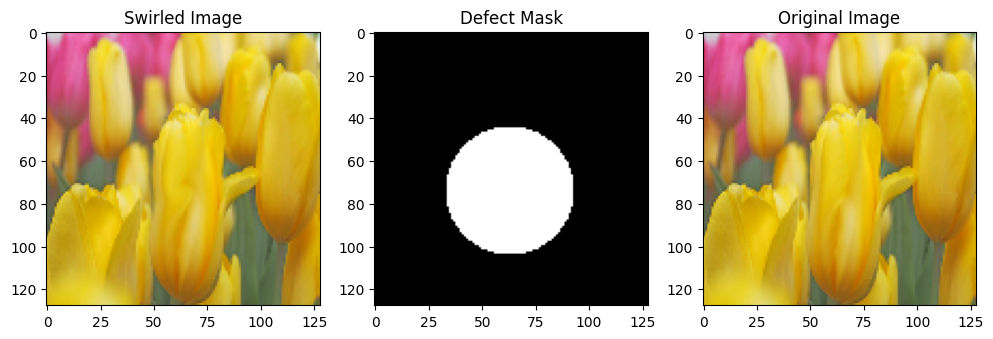

In [48]:
# Sanity check
idx = np.random.randint(0, len(test_gen) - 1)

x_batch, y_mask, y_clean = test_gen[idx]
y_clean = y_clean[:,:,:,0:3]

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(x_batch[0])
plt.title("Swirled Image")

plt.subplot(1, 3, 2)
plt.imshow(y_mask[0].squeeze(), cmap='gray')
plt.title("Defect Mask")

plt.subplot(1, 3, 3)
plt.imshow(y_clean[0])
plt.title("Original Image")
plt.show()


As you may see from the examples, the swirl is not always easily identifiable by a human. The network can locate it quite easily (you may try if you like); the actual challenge consists in correcting the effect.

A pipilene of multiple networks may be acceptable. You should not rely on the knowledge that the defect was due to a swirl.

# Evaluation metric

The generated image should be evaluated ONLY on the region corresponding to the mask. In addition this will be compared with the initial distance introduced by the swirl operation

Let us compute this "initial" error:

In [49]:
# Select a batch from the test generator
idx = np.random.randint(0, len(test_gen) - 1)
x_batch_defected, x_batch_mask, y_batch_clean = test_gen[idx]
# Compute initial distance between swirled image and original for the batch
initial_mse_imgs = np.mean((x_batch_defected - y_batch_clean)**2*x_batch_mask,axis=(1,2,3))
initial_mse_batch = np.mean(initial_mse_imgs)
print(f"Initial error introduced by swilr: {initial_mse_batch:.4f}")

Initial error introduced by swilr: 0.0008


The initial error quite low. To better emphasize the correction we compute the ratio between the resulting error and the initial one.
**This should be a value between 0 (perfect reconstruction) and 1 (no reconstruction). Higher values mean you are doing things worse.**

In [50]:
## Predict the repaired images
#generated_images = your_model.predict([x_batch_defected, x_batch_mask])
#
## Compute the distance between generated image and original for the batch
#generated_mes_batch = np.mean((generated_images - y_batch_clean_img)**2*x_batch_mask,axis=(1,2,3))
## Now let us compute the ratio, and the average over the batch
#mean_ratio = np.mean(generated_mes_batch/initial_mse_batch)
#
#print(f"Average score (Generated / Initial): {mean_ratio:.4f}")

Repeat the previous computation for all batches in testing data, and return mean and standard deviation.

# Parameters

Try to keep below 4M parameters (total, excluding parameteres of the optimizer).

You have the usual constraints:
* the project should be written in keras
* you should submit a single well documented notebook
* try to give access to weights through gdown




# Student: Lorenzo Pellegrino (0001189550)

In this project, we use a two-stage pipeline involving two separate models:

1. **Mask Prediction**

    The first model is trained to predict a binary mask that identifies the region affected by the swirl distortion. Given only the RGB input of the distorted image, the network learns to localize and isolate the corrupted area.

2. **Image Reconstruction**

    The second model performs the actual image restoration, using both the distorted image and the predicted mask. It focuses on reconstructing the damaged region while preserving the integrity of the uncorrupted areas.

## Model 1: predict mask

### Model definition
The task is fundamentally a semantic segmentation problem, so we used a classical U-Net architecture. We opted for a lightweight version to reduce the number of parameters, and also because the task appeared to be simple enough to be handled even by smaller models. This choice provided a good trade-off between performance and model size.


In [51]:
def down_block(inputs, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(inputs)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    pool = MaxPooling2D(pool_size=(2, 2))(conv)
    return conv, pool

def up_block(inputs, skip, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    up = UpSampling2D(size=(2, 2))(inputs)
    concat = Concatenate()([up, skip])
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(concat)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    return conv

def unet1(img_size=(128, 128, 3), num_classes=1, final_activation='sigmoid', base_filters=16):
    inputs = Input(shape=img_size)

    # Downsampling
    conv1, pool1 = down_block(inputs, base_filters)
    conv2, pool2 = down_block(pool1, base_filters * 2)
    conv3, pool3 = down_block(pool2, base_filters * 4)

    # Bottleneck
    conv4 = Conv2D(base_filters * 8, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(base_filters * 8, (3, 3), activation='relu', padding='same')(conv4)

    # Upsampling
    conv5 = up_block(conv4, conv3, base_filters * 4)
    conv6 = up_block(conv5, conv2, base_filters * 2)
    conv7 = up_block(conv6, conv1, base_filters)

    outputs = Conv2D(num_classes, (1, 1), activation=final_activation, padding="same")(conv7)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [52]:
mask_model = unet1(num_classes=1, final_activation='sigmoid') # returns probability mask that will be externally binarized with threshold
mask_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_37[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_38[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_39[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 32, 32,    │          0 │ conv2d_40[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_41[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ conv2d_42[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 16, 16,    │    147,584 │ conv2d_43[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 32, 32,    │          0 │ conv2d_44[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 192)              │            │ conv2d_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 32, 32,    │    110,656 │ concatenate_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_45[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 64, 64,    │          0 │ conv2d_46[0][0] 

 Total params: 487,297 (1.86 MB)

 Trainable params: 487,297 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

### Model training



#### Utils

In [53]:
def plot_false_negatives_debug(x_batch, y_true_batch, y_pred_batch, indices=None, epoch_or_batch=None, threshold=0.5, title_prefix=""):

    batch_size = x_batch.shape[0]
    if indices is None:
        indices = range(batch_size)

    plt.figure(figsize=(20, 4 * len(indices)))

    for i, idx in enumerate(indices):
        x_img = x_batch[idx]
        y_true_mask = np.squeeze(y_true_batch[idx])
        y_pred_mask = np.squeeze(y_pred_batch[idx])
        bin_mask = (y_pred_mask > threshold).astype(np.uint8)
        fn_mask = (y_true_mask == 1) & (bin_mask == 0)

        plt.subplot(len(indices), 5, i * 5 + 1)
        plt.imshow(x_img)
        plt.title("Swirled Image")
        plt.axis('off')

        plt.subplot(len(indices), 5, i * 5 + 2)
        plt.imshow(y_pred_mask, cmap='gray')
        plt.title("Raw Prediction")
        plt.axis('off')

        plt.subplot(len(indices), 5, i * 5 + 3)
        plt.imshow(bin_mask, cmap='gray')
        plt.title("Binarized Prediction")
        plt.axis('off')

        plt.subplot(len(indices), 5, i * 5 + 4)
        plt.imshow(y_true_mask, cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        plt.subplot(len(indices), 5, i * 5 + 5)
        plt.imshow(fn_mask, cmap='Reds')
        plt.title("False Negatives")
        plt.axis('off')

    title = f"{title_prefix} {epoch_or_batch} – False Negatives Debug" if epoch_or_batch is not None else "False Negatives Debug"
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [54]:
class CircleLossDebugCallback(tf.keras.callbacks.Callback):
    def __init__(self, generator, every_n_epochs=1, n_samples=3, threshold=0.5):
        super().__init__()
        self.generator = generator
        self.every_n_epochs = every_n_epochs
        self.n_samples = n_samples
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return

        x_batch, y_true_batch = next(iter(self.generator))
        y_pred_batch = self.model.predict(x_batch, verbose=0)

        indices = np.random.choice(x_batch.shape[0], self.n_samples, replace=False)
        plot_false_negatives_debug(x_batch, y_true_batch, y_pred_batch, indices=indices, epoch_or_batch=epoch + 1, threshold=self.threshold, title_prefix="Epoch")


In [55]:
def plot_history(history, logscale=False):

    loss_keys = [key for key in history.keys() if 'loss' in key]
    metric_keys = [key for key in history.keys() if 'metric' in key]  # Custom metric

    plt.figure(figsize=(12, 6))

    # Plot Loss
    plt.subplot(1, 2, 1)
    for key in loss_keys:
        plt.plot(history[key], label=key)
    if logscale:
        plt.yscale('log')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # Plot Metric
    plt.subplot(1, 2, 2)
    for key in metric_keys:
        plt.plot(history[key], label=key)
    if logscale:
        plt.yscale('log')
    plt.title('Model Metric')
    plt.ylabel('Metric Value')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()


#### Loss and metric

Since the second model relies entirely on the predicted mask to perform the restoration, it is essential that this mask is as much accurate as possible. However, accuracy alone is not sufficient due to the strong class imbalance in the dataset: a crucial important requirement is that the predicted mask fully contains the true distorted region, achieving high recall.

If the predicted mask is too small or underestimates the affected area, the second model is forced to inpaint without sufficient guidance, which leads to poor reconstructions. On the other hand, a slightly larger mask, even if it includes some false positives, is far less harmful, as the second model can still operate effectively on a superset of the true defect.

For this reason, we designed both the loss function (weighted binary cross-entropy) and the evaluation metric (asymmetric IoU) to penalize false negatives more heavily, while tolerating a greater number of false positives.


In [56]:
def weighted_bce_loss(fn_weight=5.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)  # ensures numerical stability, avoiding log(0)

        # Weighted binary cross-entropy
        bce = - (fn_weight * y_true * tf.math.log(y_pred) +
                 (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(bce)
    return loss

def asymmetric_iou_metric(fn_weight=5.0, fp_weight=1.0, threshold=0.5):
    def metric(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred > threshold, tf.float32)

        TP = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
        FP = tf.reduce_sum((1 - y_true) * y_pred, axis=[1, 2, 3])
        FN = tf.reduce_sum(y_true * (1 - y_pred), axis=[1, 2, 3])

        weighted_union = TP + fn_weight * FN + fp_weight * FP
        iou = TP / (weighted_union + 1e-8)

        return tf.reduce_mean(iou)
    return metric

#### Training configuration

In [57]:
# Generators
train_mask_gen = SwirlDefectGenerator(train_imgs, clean_batch_size=32, res="mask", n_swirl_per_image=4) # same as for original generators
test_mask_gen = SwirlDefectGenerator(test_imgs, clean_batch_size=32, res="mask", n_swirl_per_image=4)
val_mask_gen = SwirlDefectGenerator(val_imgs, clean_batch_size=32,res="mask", n_swirl_per_image=4)

# Callbacks
callbacks = [
    ReduceLROnPlateau(
        monitor="val_metric",
        mode="max",
        patience=3,
        factor=0.1,
        min_lr=1e-8,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_metric",
        mode="max",
        patience=10,  # so stops after 3 ReduceLROnPlateau
        restore_best_weights=True,
        verbose=1
    ),
    #ModelCheckpoint(
    #    filepath=folder + 'mask_model.weights.h5',
    #    monitor='val_metric',
    #    mode='max',
    #    save_best_only=True,
    #    save_weights_only=True,
    #    verbose=1
    #),
    CircleLossDebugCallback(
        generator=val_mask_gen,
        every_n_epochs=1,
        n_samples=1,
        threshold=0.5
    )

]

# Configuration
LR=1e-3
EPOCHS=100
mask_model.compile(
    optimizer=Adam(LR),
    loss=weighted_bce_loss(fn_weight=5.0),
    metrics=[asymmetric_iou_metric(fn_weight=5.0, fp_weight=1.0, threshold=0.5)]
)

# Training
#history = mask_model.fit(
#        x=train_mask_gen,
#        validation_data=val_mask_gen,
#        epochs=EPOCHS,
#        callbacks=callbacks
#)

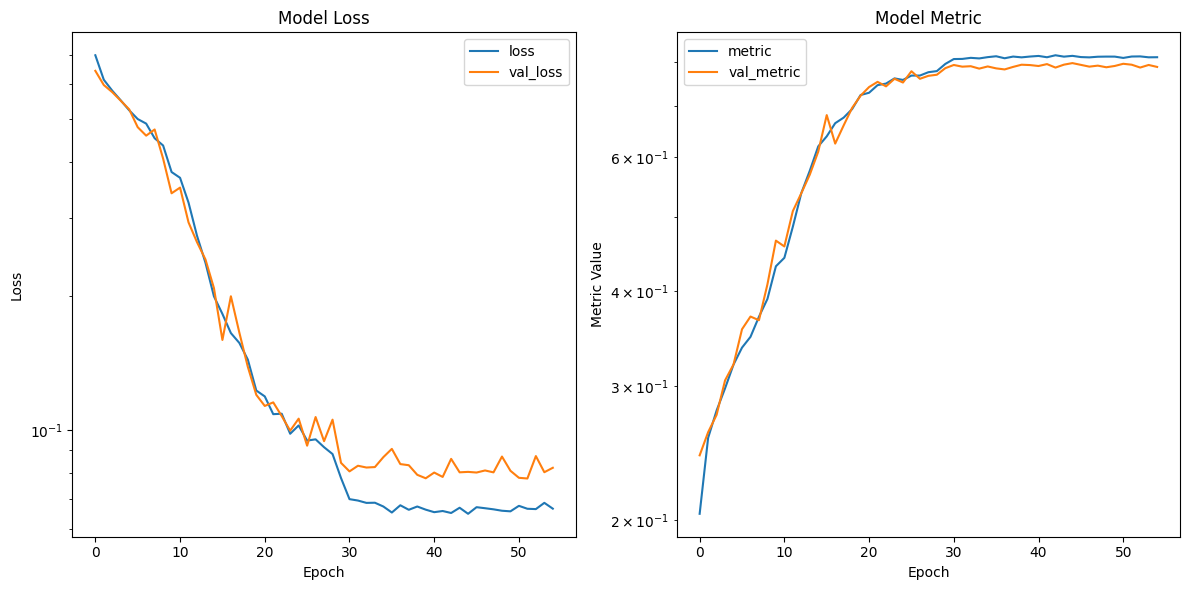

In [58]:
# Filenames
weights_file = 'mask_model.weights.h5'
history_file = 'mask_model_history.pkl'

# ID Google Drive
weights_id = '1n7w8yj7byDojomvpKQDrhTFjsoTlTodS'
history_id = '1kvW63knro3TAPLU2a9ysCCsYwsPpFGy4'

# Download
gdown.download(f'https://drive.google.com/uc?id={weights_id}', weights_file, quiet=True)
gdown.download(f'https://drive.google.com/uc?id={history_id}', history_file, quiet=True)

# Load
mask_model.load_weights(weights_file)
with open(history_file, 'rb') as f:
    history = pickle.load(f)

plot_history(history, logscale=True)


The model shows a consistent training trend, with decreasing loss and improving metrics until stabilization. Validation curves closely follow the training ones, indicating coherent behavior.

### Model result

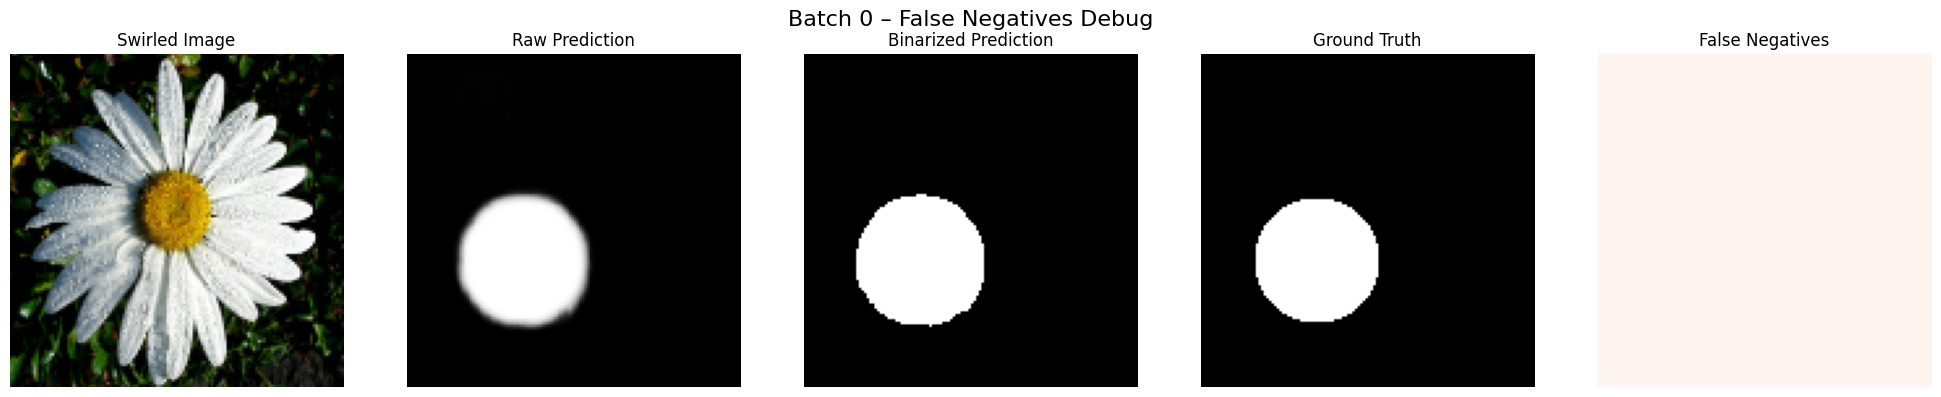

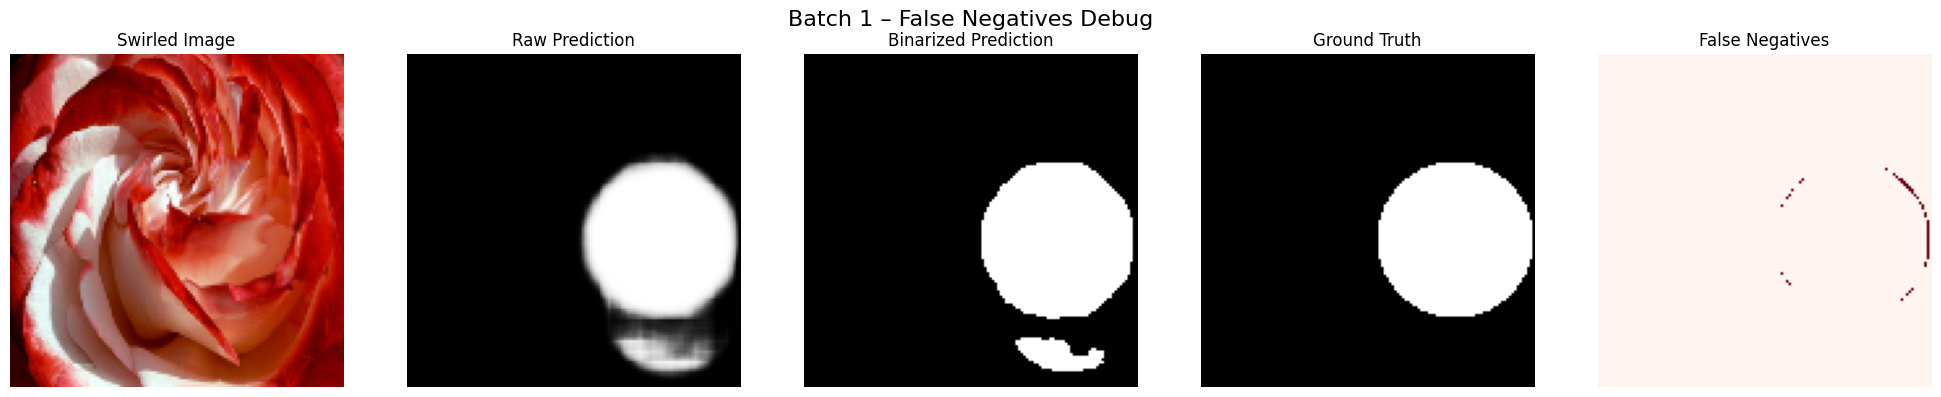

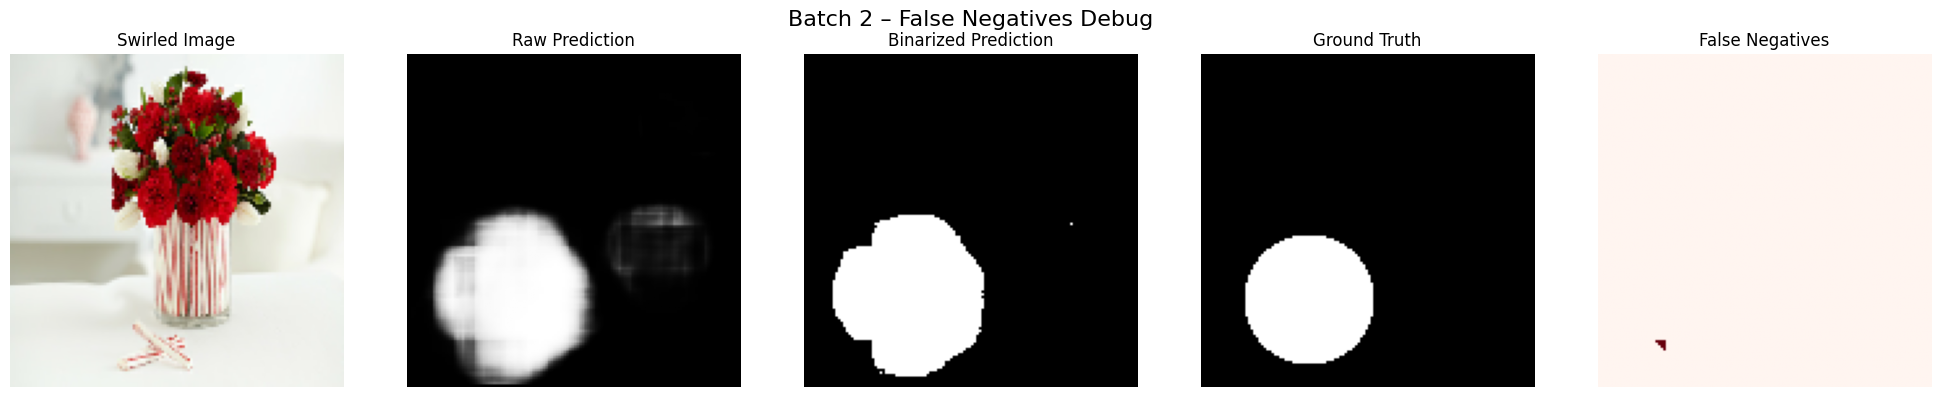

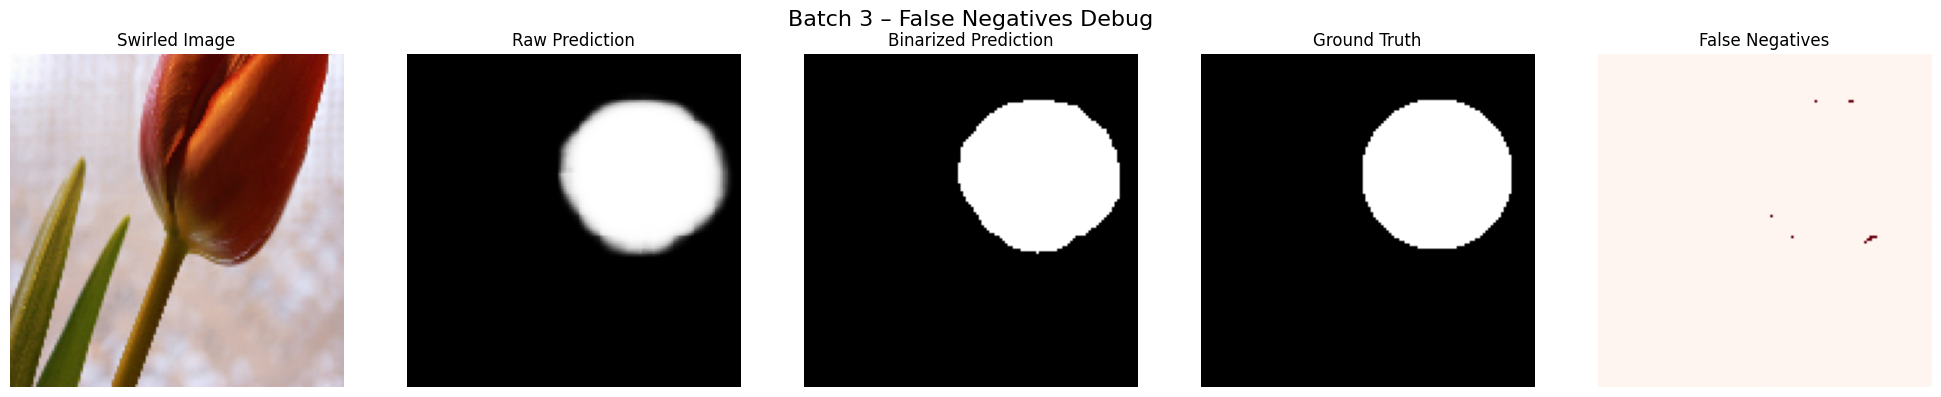

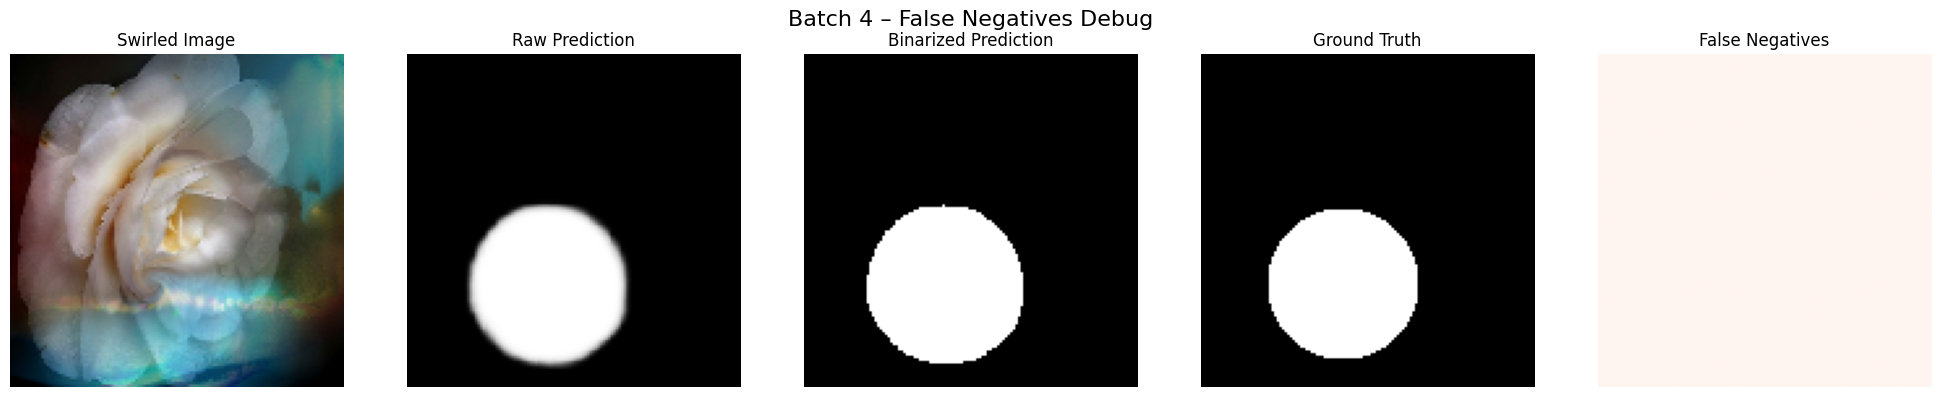

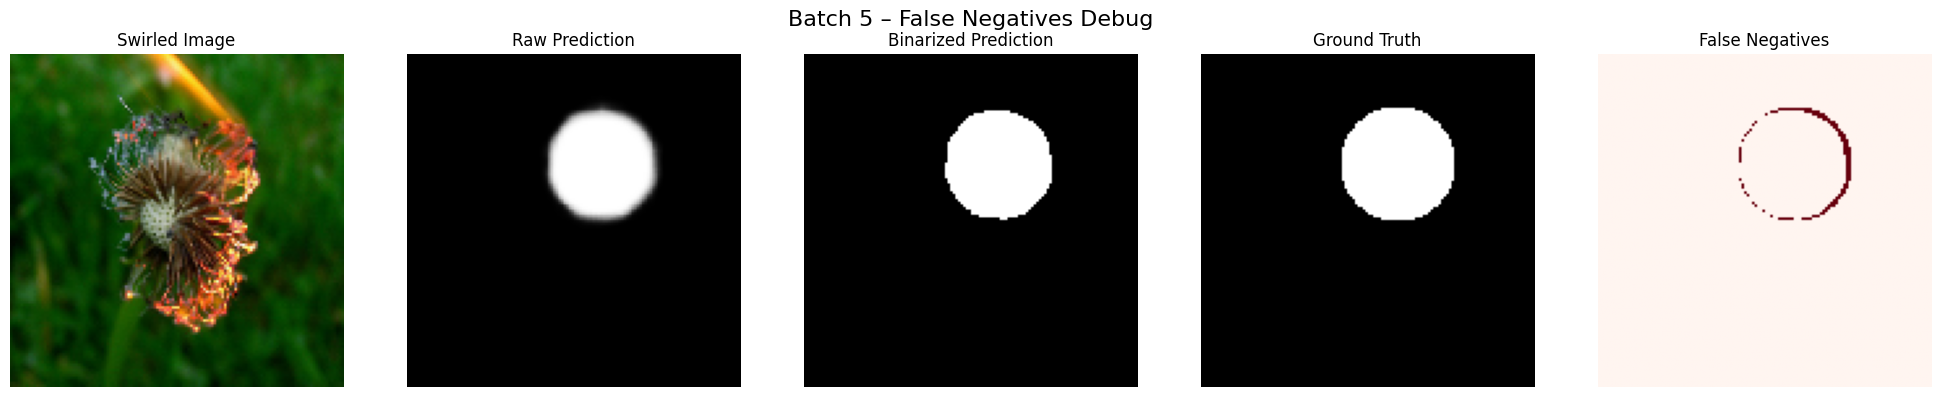

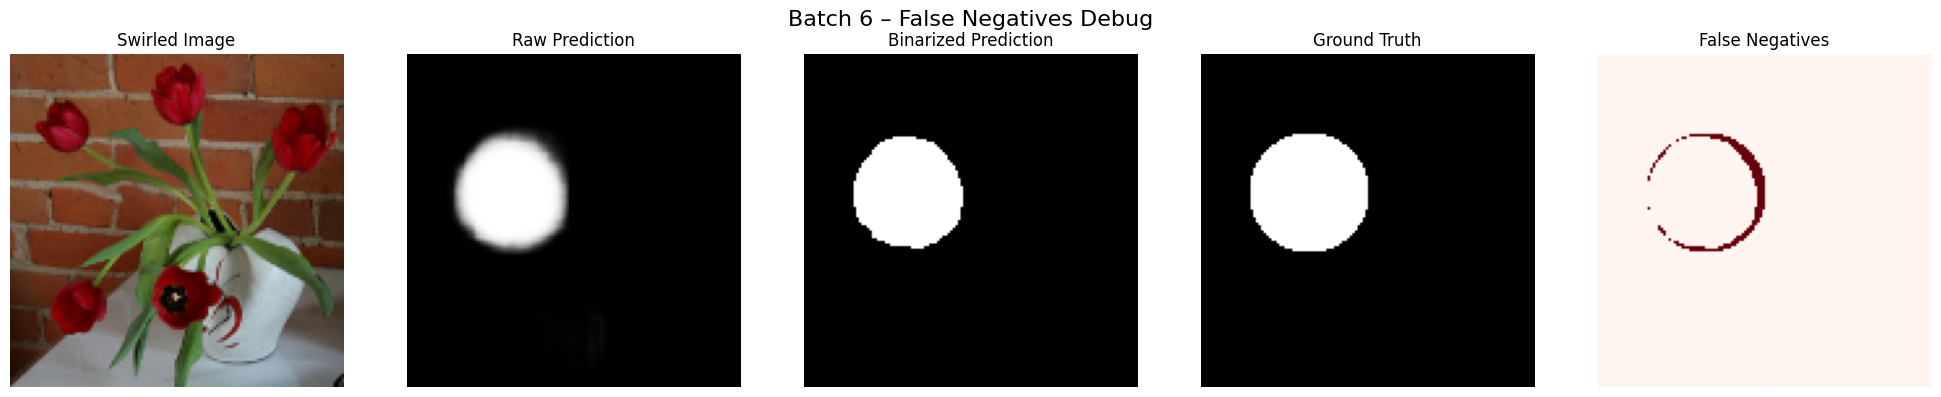

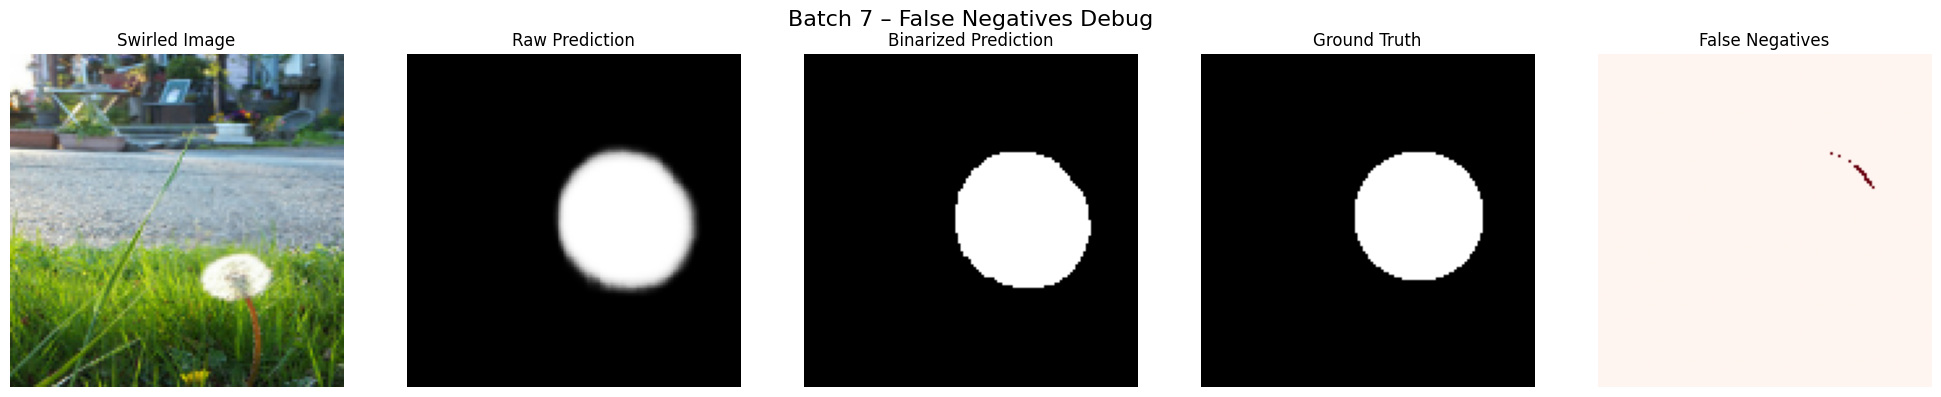

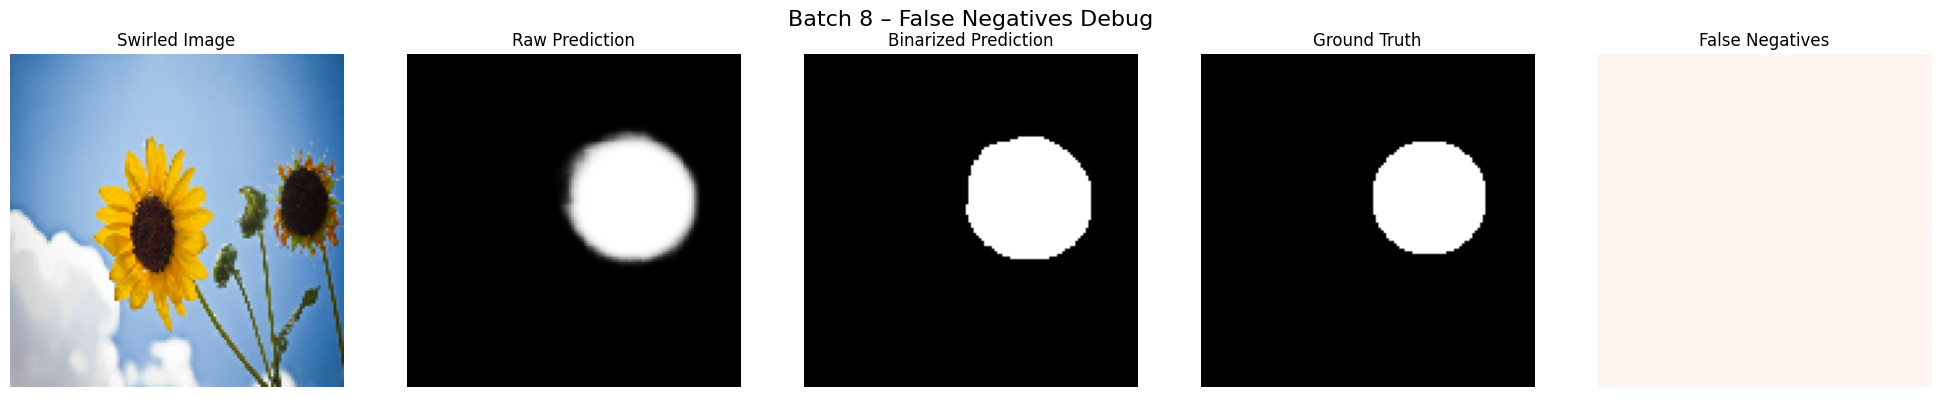

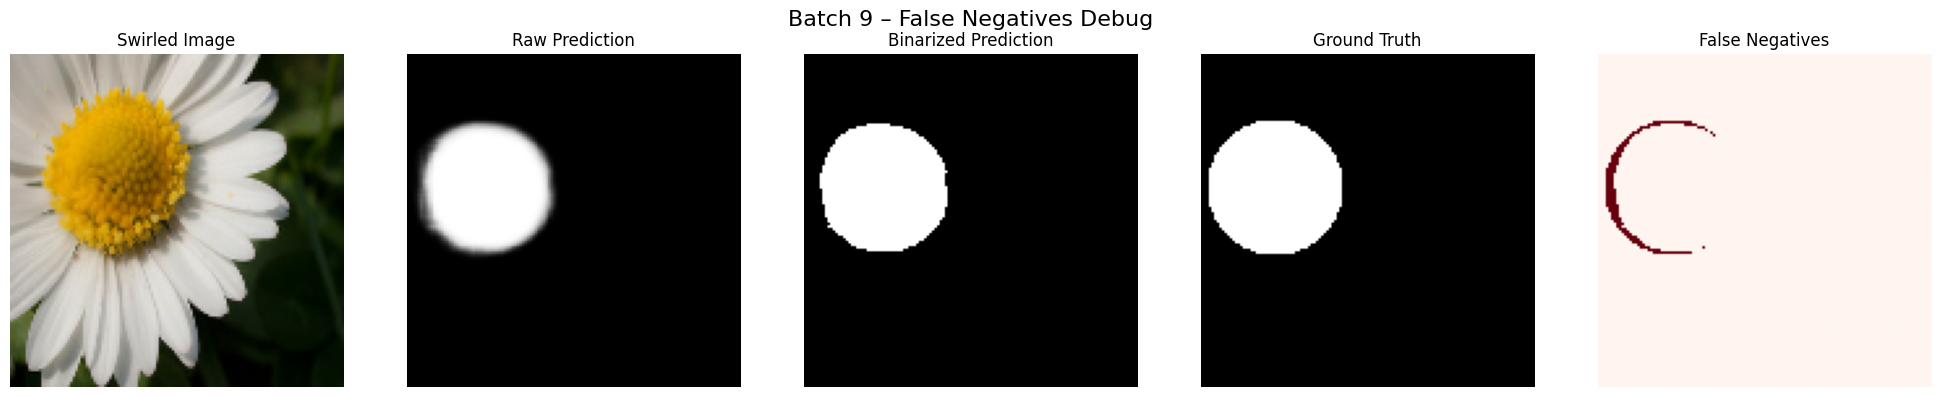

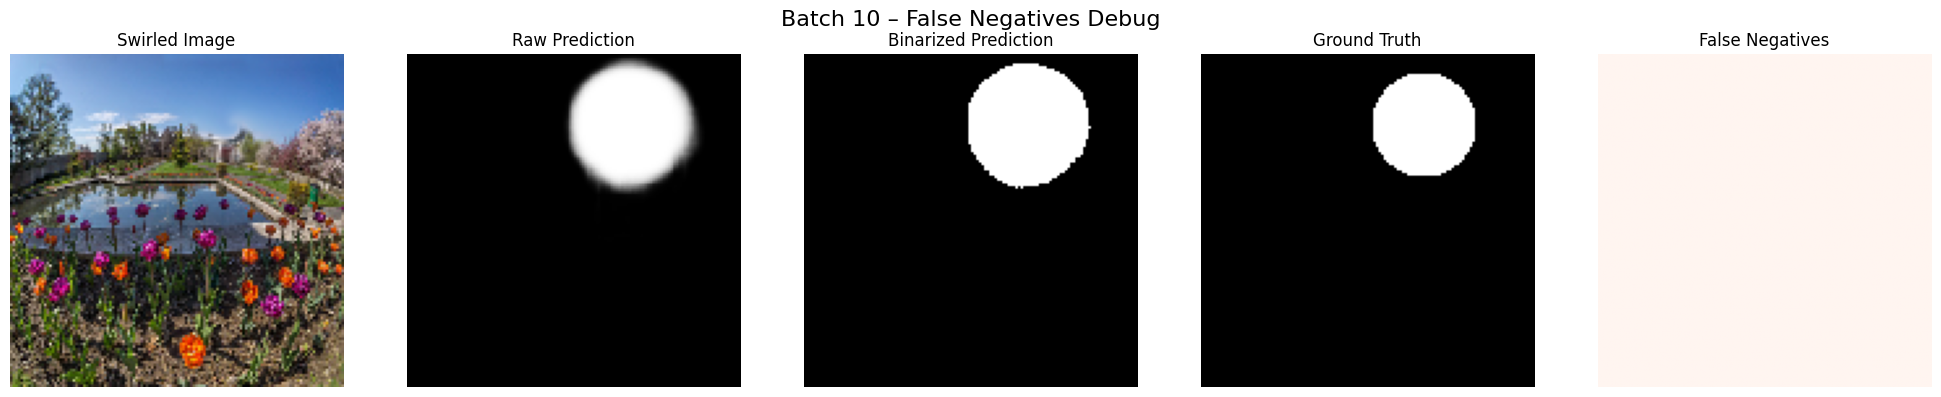

In [59]:
n = 1  # images per batch

for batch_idx in range(len(test_mask_gen)):
    x_def, y_true = test_mask_gen[batch_idx]
    y_pred_raw = mask_model.predict(x_def, verbose=0)

    indices = np.random.choice(x_def.shape[0], min(n, x_def.shape[0]), replace=False)
    plot_false_negatives_debug(x_def, y_true, y_pred_raw, indices=indices, epoch_or_batch=batch_idx, threshold=0.5, title_prefix="Batch")


As we can observe, the threshold at 0.5 is very good at approximating the true binary mask, since most of the values are very high or very low, and the predicted masks cover perfectly the true ones most of the times.

In [60]:
total_batch_iou = 0
total_batch_recall = 0
n_batches = 0

# Loop over the entire test set
for i in tqdm(range(len(test_mask_gen)), desc="Evaluating masks"):
    x_def, mask_true = test_mask_gen[i]

    # Predict the mask using the trained model
    mask_pred = mask_model.predict(x_def, verbose=0)
    mask_pred = np.squeeze(mask_pred, axis=-1)  # Remove channel dimension

    # Threshold = 0.5 is a good compromise as mask probabilities are very
    # high or very low (as onservable from previous plots)
    mask_pred_bin = (mask_pred > 0.5).astype(np.int32)
    mask_true_bin = mask_true.astype(np.int32)

    batch_iou = []
    batch_recall = []

    # Evaluate IoU and recall for each image in the batch
    for j, (pred, true) in enumerate(zip(mask_pred_bin, mask_true_bin)):
        true = np.squeeze(true, axis=-1)  # Ensure shape compatibility

        intersection = np.logical_and(pred, true).sum()
        union = np.logical_or(pred, true).sum()
        iou = intersection / (union + 1e-8)

        true_sum = true.sum()

        # Handle edge case: if the ground truth has no positive pixels
        if true_sum == 0:
            recall = 1.0 if intersection == 0 else 0.0
        else:
            recall = intersection / (true_sum + 1e-8)

        batch_iou.append(iou)
        batch_recall.append(recall)

    # Average metrics for the current batch
    total_batch_iou += np.mean(batch_iou)
    total_batch_recall += np.mean(batch_recall)
    n_batches += 1

# Mean of batch-wise averages
mean_iou = total_batch_iou / n_batches
mean_recall = total_batch_recall / n_batches

print(f"\nMean IoU on mask_model (mean of batch means):     {mean_iou:.4f}")
print(f"Mean Recall on mask_model (mean of batch means):  {mean_recall:.4f}")


Evaluating masks: 100%|██████████| 11/11 [00:13<00:00,  1.21s/it]


Mean IoU on mask_model (mean of batch means):     0.8315
Mean Recall on mask_model (mean of batch means):  0.9772


These results confirm that the mask prediction model performs well in identifying the regions affected by swirl distortions. The high recall (around 0.98) indicates that the model rarely misses parts of the actual defect, which is essential for guiding the second-stage reconstruction. Although the IoU is slightly lower (around 0.84), this is expected given the deliberate tolerance for false positives: the model tends to slightly over-segment rather than under-segment, which is a safer trade-off in this pipeline.

So the model successfully prioritizes complete coverage of the corrupted region, aligning with the design goal of maximizing recall while maintaining reasonably precise segmentation.

## Model 2: reconstruct image

### Model Definition

The network is designed to perform **localized image reconstruction**, targeting only the region specified by a binary mask. This architecture builds on the previous U-Net design, with a few important modifications added step by step that improved reconstruction quality and robustness:

- **Channels**

    The number of channels (filters) has been increased across the network. This gives the model more local capacity, allowing it to better capture texture and fine details in the corrupted region.

- **Residual Blocks**

    All convolutional stages, including the encoder, decoder, and bottleneck, are implemented as residual blocks instead of plain conv layers. These blocks help the model retain identity mappings when necessary and stabilize gradient flow.

    > **Note**: Surprisingly, adding Batch Normalization degraded performance in this setup. It introduced over-smoothing and possibly interfered with the sharpness of localized reconstructions. For this reason BatchNorm was disabled.

- **Blending**

    After generating the predicted image, we apply a blending operation using the input mask. Specifically, the model's prediction is applied only within the masked (corrupted) area, while the rest of the output is taken directly from the original swirled image.

    This simplifies the task: the network doesn't need to copy or preserve clean regions, and can focus entirely on inpainting the defective part. However, it also means the model cannot correct **false negatives** in the mask, which reinforces the importance of ensuring high recall in the first model (mask prediction).

- **Soft Attention via Mask Multiplication**

    After each decoder block (which is responsible for reconstructing spatial details from the encoded representation), the upsampled feature maps are multiplied with a resized version of the original mask. This acts as a soft attention mechanism, suppressing activations outside the predicted corrupted region and encouraging the decoder to focus on restoring the defect.


In [61]:
def blend(inputs):
  pred, swirled, mask = inputs
  return mask * pred + (1.0 - mask) * swirled

def residual_block(x, filters, kernel_size=(3, 3), padding='same', activation='relu', use_bn=True):
    shortcut = Conv2D(filters, (1, 1), padding=padding)(x)

    x = Conv2D(filters, kernel_size, padding=padding)(x)
    if use_bn:
        x = BatchNormalization()(x)
    x = Activation(activation)(x)

    x = Conv2D(filters, kernel_size, padding=padding)(x)
    if use_bn:
        x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = Activation(activation)(x)
    return x

def resize_mask_like(x):
    feature_map, mask = x
    target_size = tf.shape(feature_map)[1:3]
    return tf.image.resize(mask, target_size, method='nearest')

def up_block(x, skip, filters, mask, use_bn=True):
    up = UpSampling2D((2, 2))(x)
    concat = Concatenate()([up, skip])
    x = residual_block(concat, filters, use_bn=use_bn)

    # Resize mask to match x
    resized_mask = Lambda(resize_mask_like)([x, mask])
    x = Multiply()([x, resized_mask])
    return x

def down_block(x, filters, use_bn=True):
    conv = residual_block(x, filters, use_bn=use_bn)
    pool = MaxPooling2D((2, 2))(conv)
    return conv, pool

def unet2(img_size=(128, 128, 4), base_filters=16, use_bn=True):
    inputs = Input(shape=img_size)

    # Split input
    swirled_img = Lambda(lambda x: x[:, :, :, :3])(inputs)
    mask_input = Lambda(lambda x: x[:, :, :, 3:])(inputs)

    # Encoder
    conv1, pool1 = down_block(inputs, base_filters, use_bn=use_bn)
    conv2, pool2 = down_block(pool1, base_filters * 2, use_bn=use_bn)
    conv3, pool3 = down_block(pool2, base_filters * 4, use_bn=use_bn)

    # Bottleneck
    bottleneck = residual_block(pool3, base_filters * 8, use_bn=use_bn)

    # Decoder with attention on the mask
    up1 = up_block(bottleneck, conv3, base_filters * 4, mask_input, use_bn=use_bn)
    up2 = up_block(up1, conv2, base_filters * 2, mask_input, use_bn=use_bn)
    up3 = up_block(up2, conv1, base_filters, mask_input, use_bn=use_bn)

    # Output
    pred_clean = Conv2D(3, (1, 1), activation='sigmoid', padding='same')(up3)
    blended = Lambda(blend)([pred_clean, swirled_img, mask_input])

    return Model(inputs, blended)

rec_model = unet2(img_size=(IMG_SIZE, IMG_SIZE, 4), base_filters=32, use_bn=False)
rec_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 128, 128,  │      1,184 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 128, 128,  │          0 │ conv2d_53[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_14[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 128, 128,  │        160 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 128, 128,  │          0 │ conv2d_54[0][0],  │
│                     │ 32)               │            │ conv2d_52[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 128, 128,  │          0 │ add_7[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ activation_15[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_56 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 64,    │          0 │ conv2d_56[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_16[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 64, 64,    │      2,112 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 64,    │          0 │ conv2d_57[0][0],  │
│                     │ 64)               │            │ conv2d_55[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 64, 64,    │          0 │ add_8[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 32,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 32, 32,    │          0 │ conv2d_59[0][0] 

 Total params: 2,055,587 (7.84 MB)

 Trainable params: 2,055,587 (7.84 MB)

 Non-trainable params: 0 (0.00 B)

### Model training

#### Utils

In [62]:
class ReconstructionGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_generator, mask_model, binarize=False):
        self.base_generator = base_generator
        self.mask_model = mask_model
        self.binarize = binarize

    def __len__(self):
        return len(self.base_generator)

    def __getitem__(self, idx):
        x_defected, mask_true, x_clean = self.base_generator[idx]

        pred_mask = self.mask_model.predict(x_defected, verbose=0)
        if self.binarize:
            pred_mask = (pred_mask > 0.5).astype(np.float32)

        # NOTE: i add msk_true only for debug purposes (plots while training)
        x_input = np.concatenate([x_defected, pred_mask], axis=-1)                         # (B, H, W, 3+1)
        y_target = np.concatenate([x_clean, x_defected, pred_mask, mask_true], axis=-1)    # (B, H, W, 3+3+1+1)

        return x_input, y_target

    def on_epoch_end(self):
        self.base_generator.on_epoch_end()


In [63]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot_masked_reconstruction(
    x_input, y_target, y_pred,
    n_best=1, n_worst=0,
    sort_by="loss", title_prefix="Epoch"
):
    assert sort_by in ['loss', 'metric', 'random'], "sort_by must be 'loss', 'metric', or 'random'"

    x_clean = y_target[..., :3]
    x_defected = y_target[..., 3:6]
    pred_mask = y_target[..., 6:7]
    real_mask = y_target[..., 7:8]

    mse_masked, mse_ratio = [], []

    for i in range(x_input.shape[0]):
        numerator = np.sum((y_pred[i] - x_clean[i]) ** 2 * pred_mask[i])
        denominator = np.sum(pred_mask[i]) + 1e-8
        masked_mse = numerator / denominator
        mse_masked.append(masked_mse)

        mse_pred_metric = np.mean((y_pred[i] - x_clean[i]) ** 2 * pred_mask[i])
        mse_init_metric = np.mean((x_defected[i] - x_clean[i]) ** 2 * pred_mask[i]) + 1e-8
        ratio = mse_pred_metric / mse_init_metric
        mse_ratio.append(ratio)

    mse_masked = np.array(mse_masked)
    mse_ratio = np.array(mse_ratio)
    total_samples = x_input.shape[0]

    if sort_by == 'loss':
        best_indices = np.argsort(mse_masked)[:n_best]
        worst_indices = np.argsort(mse_masked)[-n_worst:] if n_worst > 0 else []
    elif sort_by == 'metric':
        best_indices = np.argsort(mse_ratio)[:n_best]
        worst_indices = np.argsort(mse_ratio)[-n_worst:] if n_worst > 0 else []
    else:  # sort_by == 'random'
        total = min(n_best + n_worst, total_samples)
        selected = np.random.choice(total_samples, total, replace=False)
        best_indices = selected  # treat all as "random samples"
        worst_indices = []

    def plot(idx, label):
        fig, axs = plt.subplots(1, 5, figsize=(15, 4))

        axs[0].imshow(x_defected[idx])
        axs[0].set_title("Swirled")

        axs[1].imshow(real_mask[idx].squeeze(), cmap='gray')
        axs[1].set_title("True Mask")

        axs[2].imshow(pred_mask[idx].squeeze(), cmap='gray')
        axs[2].set_title("Predicted Mask")

        axs[3].imshow(np.clip(y_pred[idx], 0, 1))
        axs[3].set_title("Reconstructed")

        axs[4].imshow(x_clean[idx])
        axs[4].set_title(
            f"{label}\nMasked MSE: {mse_masked[idx]:.4f}\nMSE Ratio: {mse_ratio[idx]:.4f}"
        )

        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    # Plotting
    if sort_by == 'random':
        for idx in best_indices:
            plot(idx, f"{title_prefix} – Random Sample")
    else:
        for idx in best_indices:
            plot(idx, f"{title_prefix} – Best by {sort_by}")
        for idx in worst_indices:
            plot(idx, f"{title_prefix} – Worst by {sort_by}")


In [64]:
class MaskedReconstructionMonitor(tf.keras.callbacks.Callback):
    def __init__(self, generator, every_n_epochs=1, n_best=1, n_worst=0, sort_by='loss'):
        super().__init__()
        self.generator = generator
        self.every_n_epochs = every_n_epochs
        self.n_best = n_best
        self.n_worst = n_worst
        self.sort_by = sort_by

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return

        x_input, y_target = next(iter(self.generator))
        y_pred = self.model.predict(x_input, verbose=0)

        analyze_and_plot_masked_reconstruction(
            x_input, y_target, y_pred,
            n_best=self.n_best,
            n_worst=self.n_worst,
            sort_by=self.sort_by,
            title_prefix=f"Epoch {epoch + 1}"
        )

#### Loss and metric

In [65]:
# It's important to note that we use pred_mask instead of the true mask,
# since the reconstruction model is not responsible for mask prediction errors.
# Using the true mask would introduce errors caused by mask mismatches that the model cannot fix.
def mse_ratio_metric(y_true, y_pred):
    clean = y_true[..., :3]
    swirled = y_true[..., 3:6]
    pred_mask = y_true[..., 6:7]
    # true_mask = y_true[..., 7:8]  # not used

    mse_pred = K.mean(K.square(y_pred - clean) * pred_mask)
    mse_swirl = K.mean(K.square(swirled - clean) * pred_mask) + K.epsilon()

    return mse_pred / mse_swirl


# It is normalized to avoid bias toward minimizing error on larger masks,
# which would naturally accumulate more total error.
# With normalization, the loss becomes scale-invariant and treats all masked regions equally.
def masked_mse_loss(y_true, y_pred):
    clean = y_true[..., :3]
    swirled = y_true[..., 3:6]
    pred_mask = y_true[..., 6:7]
    # true_mask = y_true[..., 7:8]  # not used

    numerator = tf.reduce_sum(tf.square(y_pred - clean) * pred_mask)
    denominator = tf.reduce_sum(pred_mask) + K.epsilon()   # normalizer

    return numerator / denominator

#### Training configuration

In [66]:
# Generators
train_rec_gen = ReconstructionGenerator(train_gen, mask_model, binarize=True)
test_rec_gen = ReconstructionGenerator(test_gen, mask_model, binarize=True)
val_rec_gen = ReconstructionGenerator(val_gen, mask_model, binarize=True)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor="val_mse_ratio_metric",
        restore_best_weights=True,
        start_from_epoch=0,
        patience=11,    # same reasoning of the previous training, stops after 2 ReduceLROnPlateau
        mode='min'
    ),

    ReduceLROnPlateau(
        monitor="val_mse_ratio_metric",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),

    MaskedReconstructionMonitor(
        generator=val_rec_gen,
        every_n_epochs=1,
        n_best=1,
        n_worst=1,
        sort_by='metric'  # or 'loss'
    ),

    #ModelCheckpoint(
    #    filepath=weight_file,
    #    monitor='val_mse_ratio_metric',
    #    mode='min',
    #    save_best_only=True,
    #    save_weights_only=True,
    #    verbose=1
    #)
]

# Training
LR=1e-3
EPOCHS=100

# 1) Training
rec_model.compile(
    optimizer= Adam(learning_rate=LR),
    loss=masked_mse_loss,
    metrics=[mse_ratio_metric]
)

#history = rec_model.fit(
#        x=train_rec_gen,
#        validation_data=val_rec_gen,
#        epochs=EPOCHS,
#        callbacks=callbacks
#)

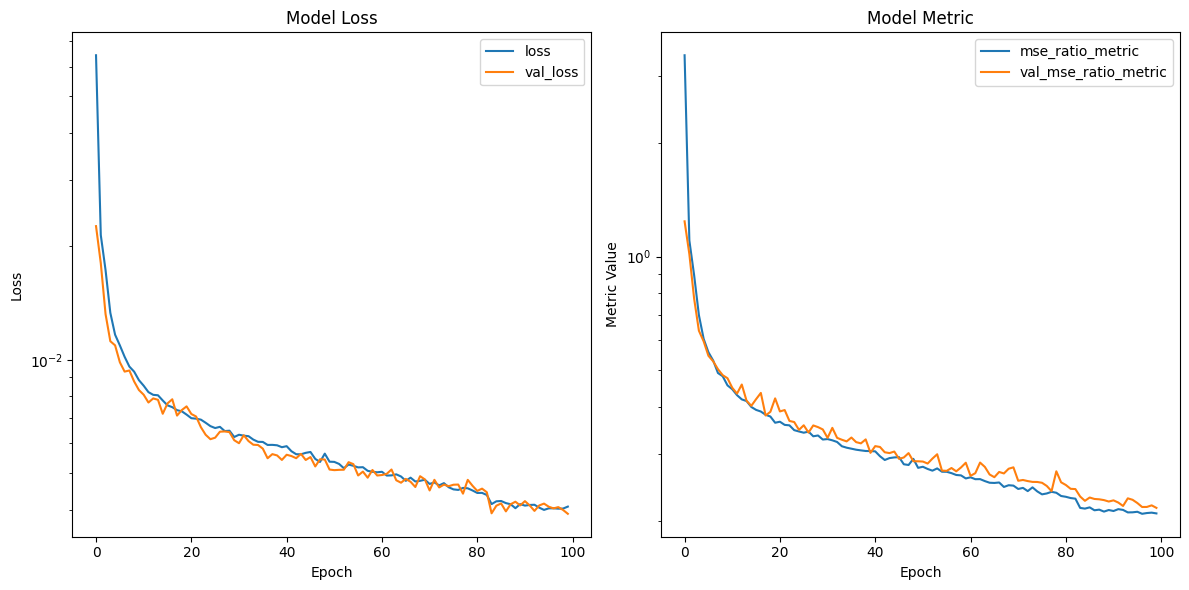

In [67]:
# Filenames
weights_file = 'rec_model.weights.h5'
history_training_file = 'rec_model_history.pkl'

# ID Google Drive
weights_id = '1pNK5Sgm6Qon-066fzubF7gpBPVMrxRwa'
history_id = '1IKIEVMMeOPuYjb48PF6nFG5Qn_baglJC'

# Download
gdown.download(f'https://drive.google.com/uc?id={weights_id}', weights_file, quiet=True)
gdown.download(f'https://drive.google.com/uc?id={history_id}', history_training_file, quiet=True)

# Load
rec_model.load_weights(weights_file)
with open(history_training_file, 'rb') as f:
    history_training = pickle.load(f)

plot_history(history_training, logscale=True)

The model shows a smooth and consistent training process, with both loss and metric steadily decreasing over time. Validation curves closely follow the training trends, suggesting stable generalization across the full 100 epochs.

### Model result

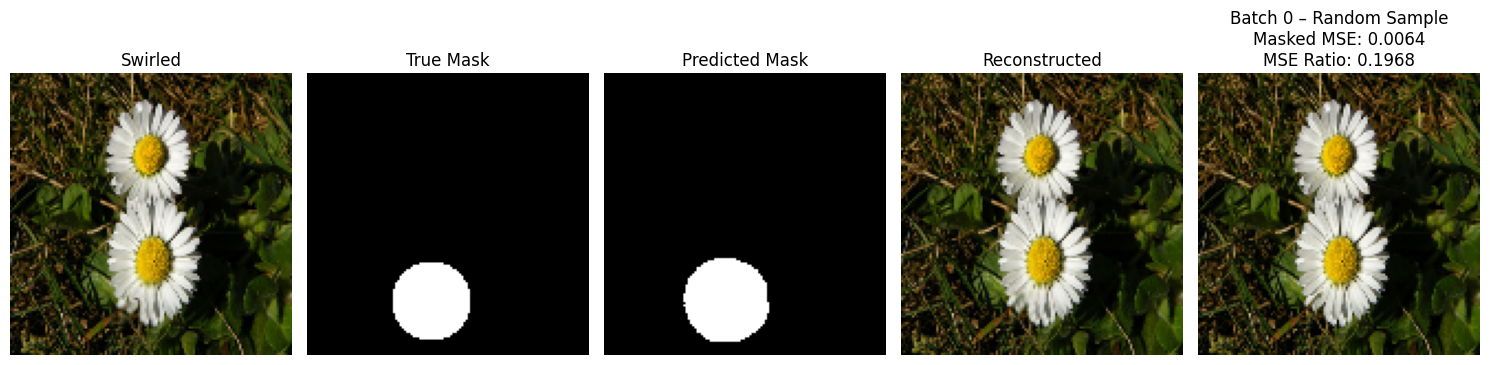

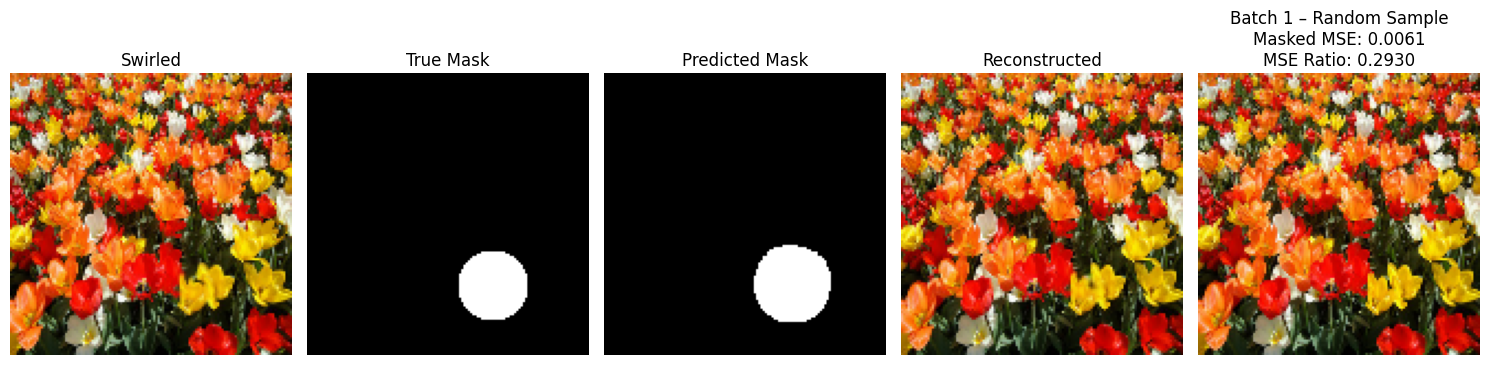

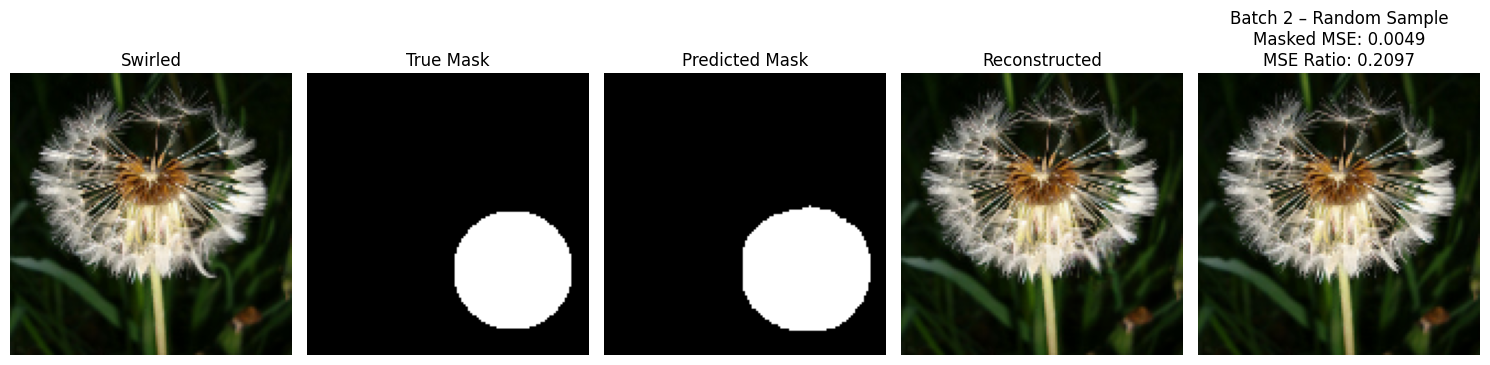

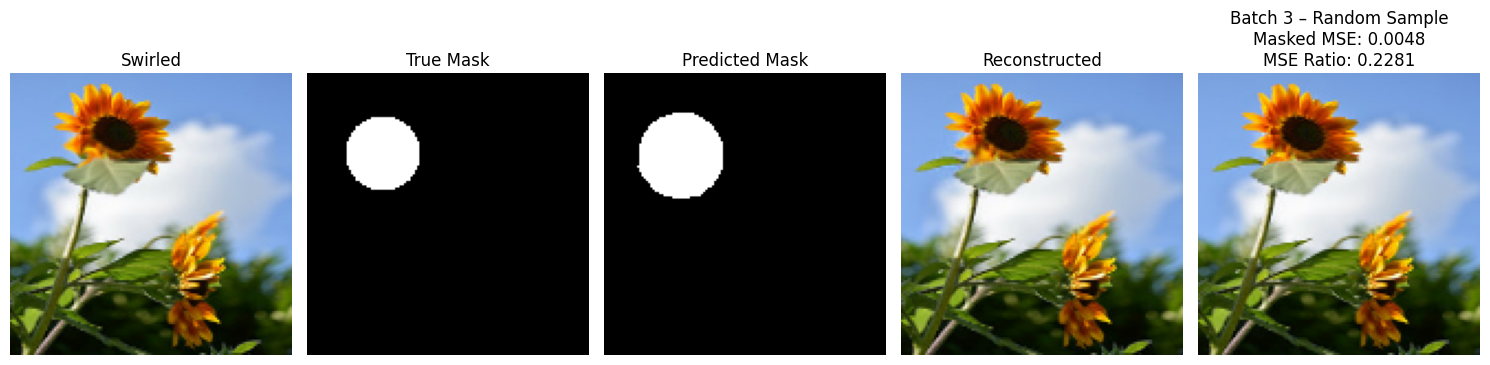

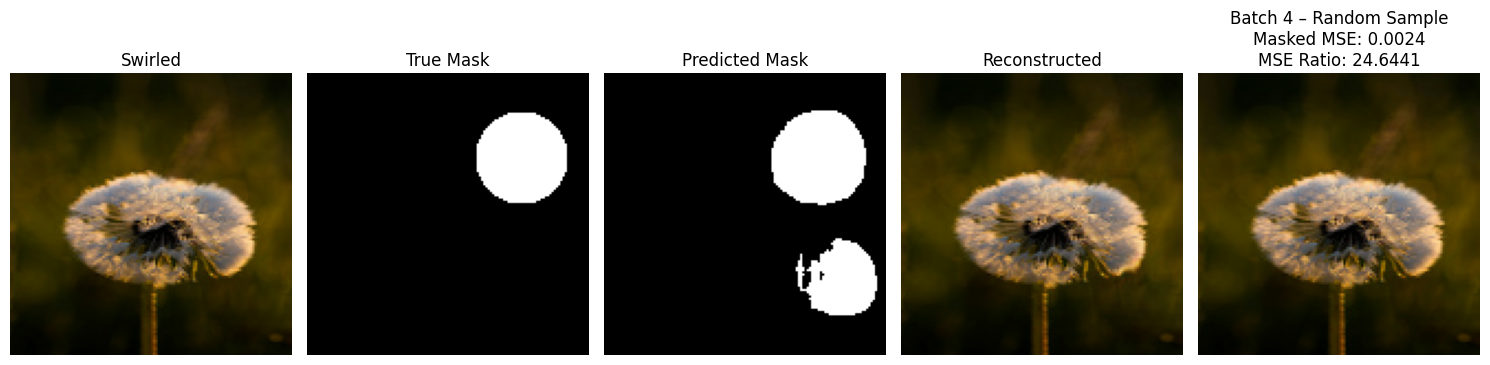

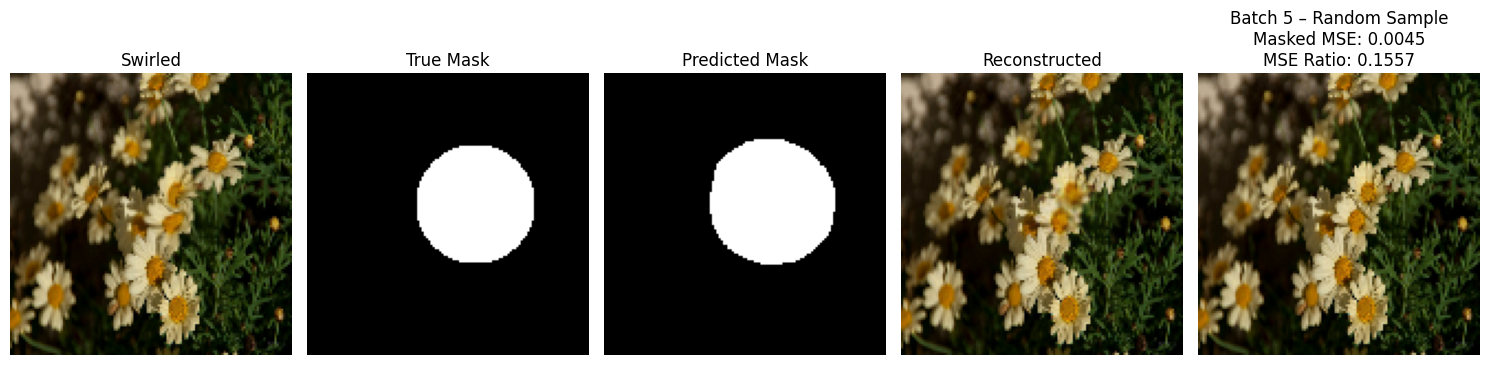

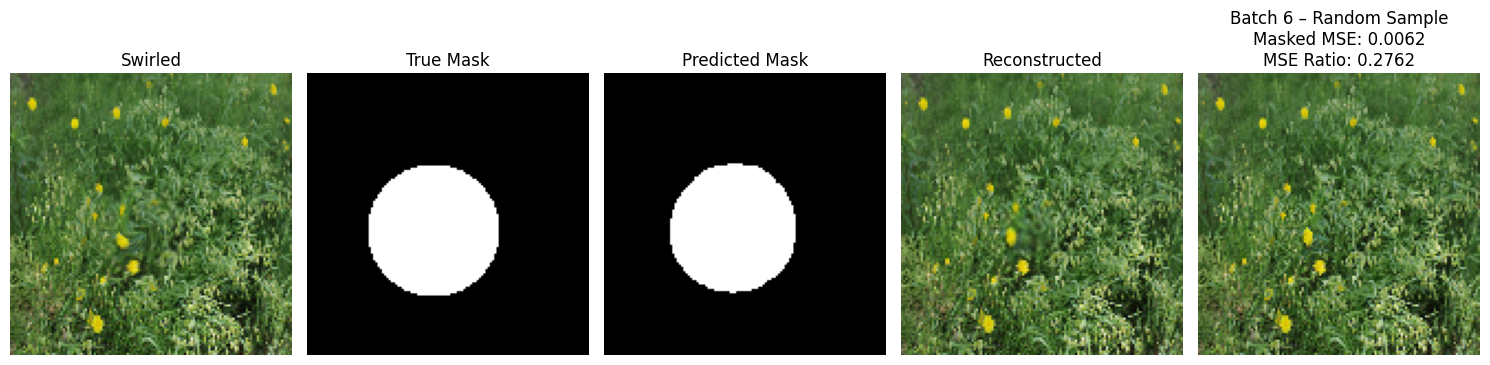

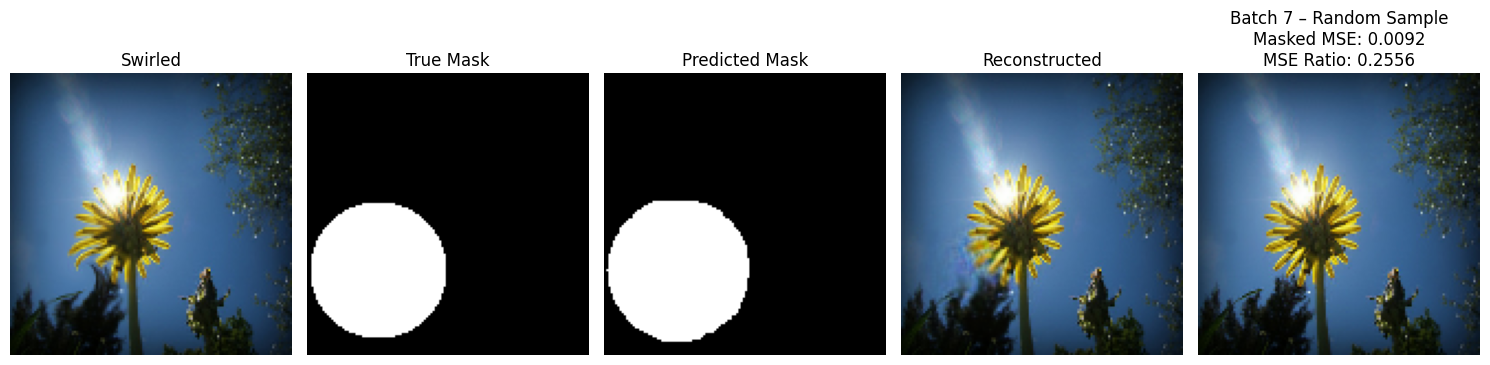

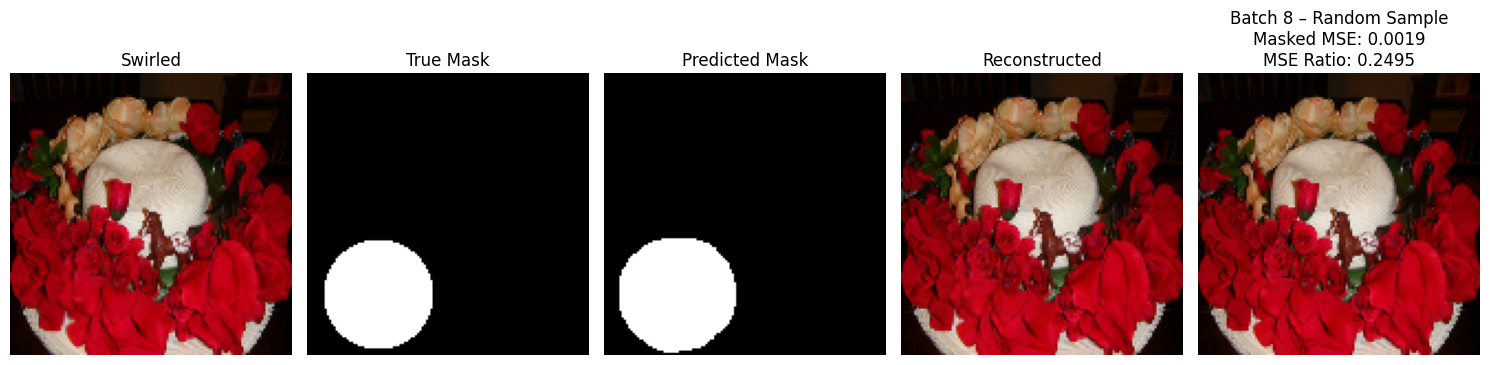

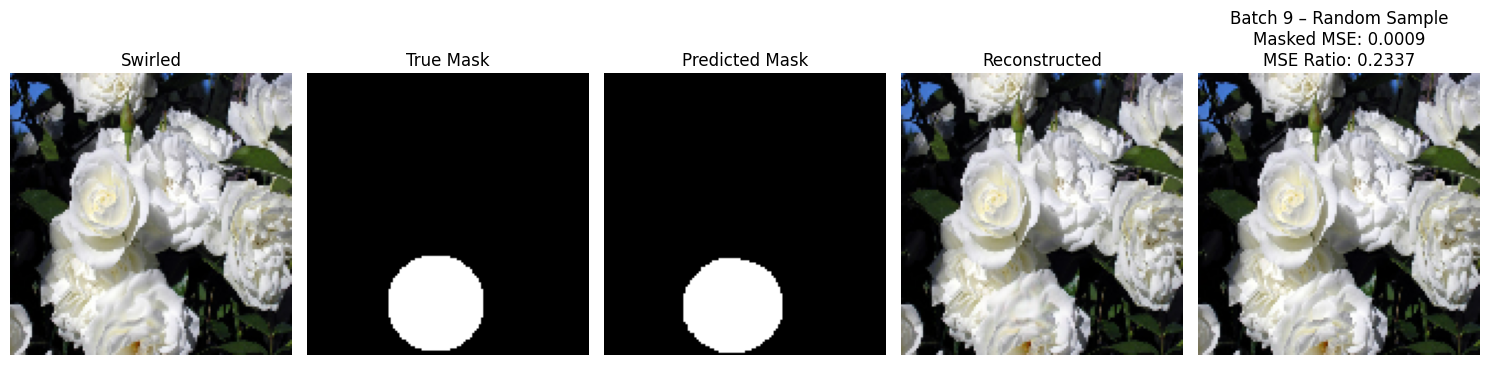

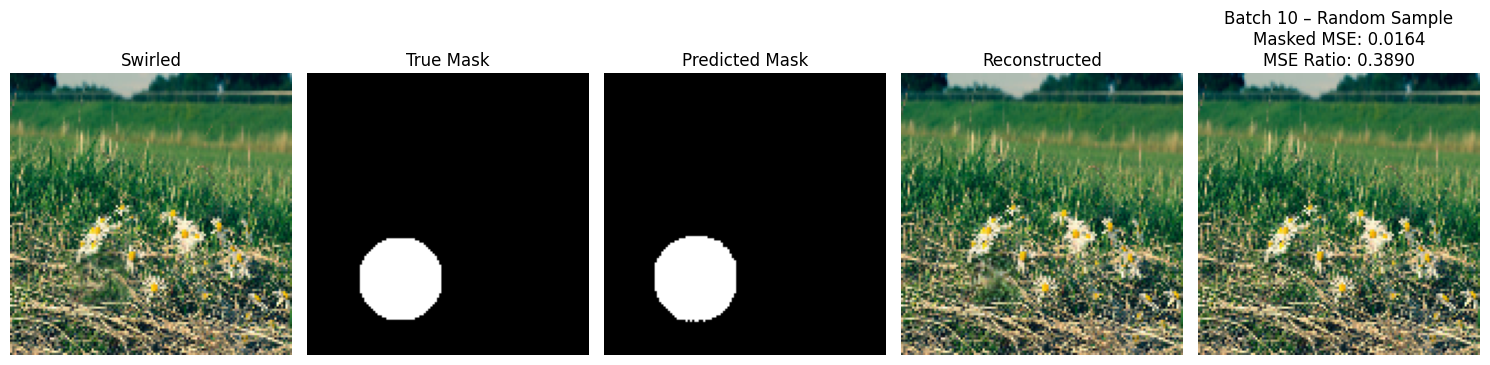

In [68]:
n_best = 1
sort_by = 'random'

for batch_idx in range(len(test_rec_gen)):
    x_input, y_target = test_rec_gen[batch_idx]
    y_pred = rec_model.predict(x_input, verbose=0)

    analyze_and_plot_masked_reconstruction(
        x_input, y_target, y_pred,
        n_best=n_best,
        sort_by=sort_by,
        title_prefix=f"Batch {batch_idx}"
    )

## Models evaluation

In [69]:
final = []
for i in range(len(test_gen)):
    x_batch_defected, x_batch_mask, y_batch_clean = test_gen[i]

    # Compute MSE of swirl vs clean
    initial_mse_imgs = np.mean((x_batch_defected - y_batch_clean)**2 * x_batch_mask, axis=(1, 2, 3))
    initial_mse_batch = np.mean(initial_mse_imgs) + 1e-8

    # Predict repaired images
    predicted_mask = mask_model.predict(x_batch_defected, verbose=0)
    predicted_mask = (predicted_mask > 0.5).astype(np.float32)

    input_for_model2 = np.concatenate([x_batch_defected, predicted_mask], axis=-1)
    generated_images = rec_model.predict(input_for_model2, verbose=0)

    # Compute MSE of repaired vs clean
    generated_mse_imgs = np.mean((generated_images - y_batch_clean)**2 * x_batch_mask, axis=(1, 2, 3))
    mean_ratio = np.mean(generated_mse_imgs / initial_mse_batch)

    final.append(mean_ratio)

final = np.array(final)
mean_performance = final.mean()
std_performance = final.std()

print(f"Mean: {mean_performance:.4f}, Std: {std_performance:.4f}")
print(f"Total number of parameters : {mask_model.count_params() + rec_model.count_params()}")

Mean: 0.1976, Std: 0.0112
Total number of parameters : 2542884


The results show a stable improvement around 80% with approximately half of the constrained total number of parameters, suggesting that further improvements are maybe still possibile increasing parameters and exploring other training recipies in both models.